In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Model 4 v3: BiMamba + Transformer — PhenoCrop

**Score history:**
- v1 (Perceiver bottleneck): 0.62
- v2 (Mamba pre-enc + Transformer): 0.73
- **v3 target:** 0.78–0.82

**Three fixes from v2 → v3:**

| Issue in v2 | Fix in v3 |
|---|---|
| Mamba scans left→right only (misses future context) | **Bidirectional Mamba** (fwd + bwd, like BiGRU) |
| Pos encoding added AFTER Mamba (Mamba is blind to time order) | **Pos+channel embed added BEFORE Mamba** |
| Cross-entropy + label smoothing 0.1 (too soft) | **Focal loss** (γ=1.5, weighted) |

**Architecture:**
```
S1 [B,T,3] + pos_enc + ch_emb → BiMambaBlock × 2  ─┐
S2 [B,T,9] + pos_enc + ch_emb → BiMambaBlock × 2  ─┤
                                                      concat → [B,2T,d]
                                                      TransformerBlock × 4
                                                      masked mean-pool
                                                      MLP → 5 classes
```

## Cell 1 — Imports & Config

In [ ]:
from pathlib import Path
import math, random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    confusion_matrix, classification_report,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DATASET_ROOT   = "/content/drive/MyDrive/pheno_crop_v2"
LOCAL_FALLBACK = Path("./dataset/pheno_crop_v2")
OUTPUT_DIR     = Path("./models")

root = Path(DATASET_ROOT)
if not root.exists() and LOCAL_FALLBACK.exists():
    root = LOCAL_FALLBACK.resolve()
    print(f"Local fallback: {root}")

s1_dir  = root / "sentinel_1"
s2_dir  = root / "sentinel_2"
gt_path = root / "ground_truth.csv"
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"gt: {gt_path.exists()} | CUDA: {torch.cuda.is_available()}")

gt: True | CUDA: True


## Cell 2 — Labels & Split

In [ ]:
gt = pd.read_csv(gt_path)
gt["date"] = pd.to_datetime(gt["date"])

stage_names  = sorted(gt["stage_name"].dropna().unique())
stage_to_idx = {n: i for i, n in enumerate(stage_names)}
idx_to_stage = {i: n for n, i in stage_to_idx.items()}
gt["stage_idx"] = gt["stage_name"].map(stage_to_idx)
num_classes = len(stage_names)
print(f"Classes ({num_classes}): {stage_to_idx}")

plot_df = pd.DataFrame({"plot_id": sorted(gt["plot_id"].unique())})
gss = GroupShuffleSplit(1, test_size=0.15, random_state=SEED)
tv_idx, te_idx = next(gss.split(plot_df, groups=plot_df["plot_id"]))
tv_df      = plot_df.iloc[tv_idx].reset_index(drop=True)
test_plots = set(plot_df.iloc[te_idx]["plot_id"])

gss2 = GroupShuffleSplit(1, test_size=0.1765, random_state=SEED)
tr_idx, va_idx = next(gss2.split(tv_df, groups=tv_df["plot_id"]))
train_plots = set(tv_df.iloc[tr_idx]["plot_id"])
val_plots   = set(tv_df.iloc[va_idx]["plot_id"])

assert train_plots.isdisjoint(val_plots) and train_plots.isdisjoint(test_plots)
train_rows = gt[gt["plot_id"].isin(train_plots)]
val_rows   = gt[gt["plot_id"].isin(val_plots)]
test_rows  = gt[gt["plot_id"].isin(test_plots)]
print(f"Plots: train={len(train_plots)} val={len(val_plots)} test={len(test_plots)}")

Classes (5): {'Bare': 0, 'Growth': 1, 'Ripening': 2, 'Seedling': 3, 'Tillering': 4}
Plots: train=142 val=31 test=31


## Cell 3 — Dataset

In [ ]:
S1_COLS  = ["VV", "VH", "VH_VV_Ratio"]
S2_COLS  = ["NDVI", "NDWI", "NDRE", "EVI", "SAVI", "MSAVI", "NDMI", "GNDVI", "cloud_pct"]

# v3: slightly larger temporal window for richer context
LOOKBACK = 120   # was 90 in v2
MAX_T    = 40    # was 30 in v2


class PhenoCropDataset(Dataset):
    def __init__(self, gt_df, s1_dir, s2_dir, augment=False):
        self.gt      = gt_df.sort_values(["plot_id", "date"]).reset_index(drop=True)
        self.augment = augment
        self.s1_cache, self.s2_cache = {}, {}
        for pid in sorted(self.gt["plot_id"].unique()):
            p1 = Path(s1_dir) / f"plot_{pid}_sar.csv"
            p2 = Path(s2_dir) / f"plot_{pid}_indices.csv"
            if p1.exists():
                d = pd.read_csv(p1); d["date"] = pd.to_datetime(d["date"])
                self.s1_cache[pid] = d
            if p2.exists():
                d = pd.read_csv(p2); d["date"] = pd.to_datetime(d["date"])
                self.s2_cache[pid] = d

    def __len__(self): return len(self.gt)

    def _window(self, df, target_date, cols):
        feats    = np.zeros((MAX_T, len(cols)), dtype=np.float32)
        days_arr = np.zeros(MAX_T, dtype=np.int64)
        valid    = np.zeros(MAX_T, dtype=bool)
        if df is None or df.empty:
            return feats, days_arr, valid
        for c in cols:
            if c not in df.columns: df[c] = 0.0
        start = target_date - pd.Timedelta(days=LOOKBACK)
        win = df[(df["date"] > start) & (df["date"] <= target_date)].sort_values("date")
        if win.empty:
            return feats, days_arr, valid
        n = min(len(win), MAX_T)
        feats[-n:]    = win[cols].fillna(0.0).to_numpy(dtype=np.float32)[-n:]
        d_ago = (target_date - win["date"]).dt.days.to_numpy(dtype=np.int64)
        days_arr[-n:] = d_ago[-n:]
        valid[-n:]    = True
        return feats, days_arr, valid

    def _augment(self, feats, valid):
        """Training augmentations: jitter + random timestep masking."""
        # Small Gaussian jitter on valid features
        noise = np.random.randn(*feats.shape).astype(np.float32) * 0.02
        feats = feats + noise * valid[:, None]
        # Randomly mask up to 20% of valid timesteps
        if valid.sum() > 3:
            n_mask = max(1, int(valid.sum() * 0.20))
            valid_idx = np.where(valid)[0]
            mask_idx  = np.random.choice(valid_idx, size=n_mask, replace=False)
            feats[mask_idx] = 0.0
            valid[mask_idx] = False
        return feats, valid

    def __getitem__(self, idx):
        row   = self.gt.iloc[idx]
        pid   = int(row["plot_id"])
        tdate = row["date"]
        label = int(row["stage_idx"])

        s1f, s1d, s1v = self._window(self.s1_cache.get(pid), tdate, S1_COLS)
        s2f, s2d, s2v = self._window(self.s2_cache.get(pid), tdate, S2_COLS)

        if self.augment:
            s1f, s1v = self._augment(s1f, s1v.copy())
            s2f, s2v = self._augment(s2f, s2v.copy())

        days_ago = np.where(s2v, s2d, s1d)
        return {
            "s1":      torch.tensor(s1f),
            "s2":      torch.tensor(s2f),
            "days":    torch.tensor(days_ago).long(),
            "s1_mask": torch.tensor(~s1v),
            "s2_mask": torch.tensor(~s2v),
            "label":   torch.tensor(label).long(),
        }


# Train set gets augmentation
train_ds = PhenoCropDataset(train_rows, s1_dir, s2_dir, augment=True)
val_ds   = PhenoCropDataset(val_rows,   s1_dir, s2_dir, augment=False)
test_ds  = PhenoCropDataset(test_rows,  s1_dir, s2_dir, augment=False)
print(f"Datasets: {len(train_ds)} / {len(val_ds)} / {len(test_ds)}")

Datasets: 16330 / 3565 / 3565


## Cell 4 — Bidirectional Mamba Block

**Key fix vs v2:** Mamba is inherently causal (left→right). Phenology classification benefits from context in both directions (e.g. knowing what comes after helps identify current stage). BiMamba runs forward + backward SSMs and merges them — mirrors the success of BiGRU in model_2.

In [ ]:
class _MambaCore(nn.Module):
    """Single-direction Mamba SSM core (pure PyTorch)."""

    def __init__(self, d_model: int, d_state: int = 16, expand: int = 2, d_conv: int = 4):
        super().__init__()
        self.d_inner = d_model * expand
        self.d_state = d_state

        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True,
        )
        self.x_proj   = nn.Linear(self.d_inner, d_state * 2 + self.d_inner, bias=False)
        self.dt_proj  = nn.Linear(self.d_inner, self.d_inner, bias=True)
        A = torch.arange(1, d_state + 1, dtype=torch.float32)\
               .unsqueeze(0).expand(self.d_inner, -1)
        self.A_log    = nn.Parameter(torch.log(A))
        self.D        = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)

    def _ssm(self, u, dt, A, B, C):
        B_sz, L, d = u.shape
        dA = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0))
        dB = dt.unsqueeze(-1) * B.unsqueeze(2)
        h  = torch.zeros(B_sz, d, self.d_state, device=u.device, dtype=u.dtype)
        ys = []
        for t in range(L):
            h  = dA[:, t] * h + dB[:, t] * u[:, t].unsqueeze(-1)
            ys.append((h * C[:, t].unsqueeze(1)).sum(-1))
        return torch.stack(ys, dim=1)

    def forward(self, x):
        B_sz, L, _ = x.shape
        xz  = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_  = self.conv1d(x_.transpose(1,2))[:, :, :L].transpose(1,2)
        x_  = F.silu(x_)
        tmp = self.x_proj(x_)
        Bs  = tmp[..., :self.d_state]
        Cs  = tmp[..., self.d_state:2*self.d_state]
        dt  = F.softplus(self.dt_proj(tmp[..., 2*self.d_state:]))
        A   = -torch.exp(self.A_log)
        y   = self._ssm(x_, dt, A, Bs, Cs)
        y   = y + x_ * self.D
        y   = y * F.silu(z)
        return self.out_proj(y)


class BiMambaBlock(nn.Module):
    """
    Bidirectional Mamba block.

    Runs two Mamba cores:
      - Forward:  processes sequence left → right
      - Backward: processes reversed sequence, then flips back
    Outputs are summed and projected back.

    Input/Output: [B, L, d_model]
    """

    def __init__(self, d_model: int, d_state: int = 16, expand: int = 2,
                 d_conv: int = 4, drop: float = 0.1):
        super().__init__()
        self.norm    = nn.LayerNorm(d_model)
        self.fwd     = _MambaCore(d_model, d_state, expand, d_conv)
        self.bwd     = _MambaCore(d_model, d_state, expand, d_conv)
        # Merge fwd+bwd → d_model
        self.merge   = nn.Linear(d_model * 2, d_model, bias=False)
        self.drop    = nn.Dropout(drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = x
        x = self.norm(x)

        y_fwd = self.fwd(x)                            # [B, L, d_model]
        y_bwd = self.bwd(x.flip(1)).flip(1)            # reverse, process, flip back

        y = self.merge(torch.cat([y_fwd, y_bwd], dim=-1))  # [B, L, d_model]
        return residual + self.drop(y)

## Cell 5 — Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, d: int, n_heads: int, mlp_ratio: float = 2.0, drop: float = 0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d)
        self.attn  = nn.MultiheadAttention(d, n_heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(d)
        self.mlp   = nn.Sequential(
            nn.Linear(d, int(d * mlp_ratio)), nn.GELU(), nn.Dropout(drop),
            nn.Linear(int(d * mlp_ratio), d), nn.Dropout(drop),
        )

    def forward(self, x, key_padding_mask=None):
        h = self.norm1(x)
        h, _ = self.attn(h, h, h, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + h
        x = x + self.mlp(self.norm2(x))
        return x

## Cell 6 — PhenoCropBiMambaTransformer Model

**Key fix vs v2:** Positional + channel embeddings are added **before** BiMamba, so the SSM has full temporal context when building local features.

In [ ]:
def sinusoid_table(n_pos: int, d_hid: int) -> torch.Tensor:
    pos = torch.arange(n_pos).float().unsqueeze(1)
    dim = torch.arange(d_hid).float().unsqueeze(0)
    a   = pos / torch.pow(10000, 2 * (dim // 2) / d_hid)
    a[:, 0::2] = torch.sin(a[:, 0::2])
    a[:, 1::2] = torch.cos(a[:, 1::2])
    return a


def month_table(d_hid: int) -> torch.Tensor:
    assert d_hid % 2 == 0
    ang = torch.arange(12).float() / 12 * 2 * math.pi
    return torch.cat([
        torch.sin(ang).unsqueeze(1).expand(-1, d_hid // 2),
        torch.cos(ang).unsqueeze(1).expand(-1, d_hid // 2),
    ], dim=-1)


class PhenoCropBiMambaTransformer(nn.Module):
    """
    BiMamba per-modality encoder (pos-aware) + Transformer cross-modal fusion.

    v3 improvements over v2:
      1. Bidirectional Mamba (fwd + bwd) — richer temporal context
      2. Pos/channel embed added BEFORE BiMamba (position-aware SSM)
      3. Focal loss support (handled in training cell)
      4. Larger temporal window (MAX_T=40, LOOKBACK=120)
    """

    MAX_DAYS = 130
    N_GROUPS = 2

    def __init__(
        self,
        d_model:      int   = 128,
        mamba_depth:  int   = 2,
        tf_depth:     int   = 4,
        n_heads:      int   = 8,
        d_state:      int   = 16,
        mlp_ratio:    float = 2.0,
        drop:         float = 0.1,
        num_classes:  int   = 5,
    ):
        super().__init__()
        assert d_model % 4 == 0
        self.d_pos   = d_model // 2
        self.d_ch    = d_model // 4
        self.d_month = d_model // 4

        # Input projections
        self.s1_proj = nn.Linear(len(S1_COLS), d_model)
        self.s2_proj = nn.Linear(len(S2_COLS), d_model)

        # Positional / channel / month embeddings (Presto-style split)
        self.channel_embed = nn.Embedding(self.N_GROUPS, self.d_ch)
        self.register_buffer("pos_tab",   sinusoid_table(self.MAX_DAYS + 1, self.d_pos))
        self.register_buffer("month_tab", month_table(self.d_month))

        # BiMamba per-modality (pos applied BEFORE)
        self.s1_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state=d_state, drop=drop)
            for _ in range(mamba_depth)
        ])
        self.s2_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state=d_state, drop=drop)
            for _ in range(mamba_depth)
        ])

        # Global Transformer fusion
        self.tf_blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, mlp_ratio, drop)
            for _ in range(tf_depth)
        ])
        self.norm = nn.LayerNorm(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(d_model // 2, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def _make_pos(self, days, group_idx, B, T, device):
        """Build Presto-style positional embedding [B, T, d_model] for one modality group."""
        pos_enc   = self.pos_tab[days.clamp(0, self.MAX_DAYS)]   # [B,T,d_pos]
        month_enc = self.month_tab[(1 - (days // 30).clamp(0,11)) % 12]  # [B,T,d_month]
        ch_enc    = self.channel_embed(
            torch.tensor(group_idx, device=device)
        ).unsqueeze(0).unsqueeze(0).expand(B, T, -1)              # [B,T,d_ch]
        return torch.cat([pos_enc, ch_enc, month_enc], dim=-1)    # [B,T,d_model]

    def forward(self, s1, s2, days, s1_mask, s2_mask):
        B, T, _ = s1.shape
        device   = s1.device

        tokens_list, mask_list = [], []
        for g_idx, (proj, bimamba, feat, mask) in enumerate([
            (self.s1_proj, self.s1_bimamba, s1, s1_mask),
            (self.s2_proj, self.s2_bimamba, s2, s2_mask),
        ]):
            tok = proj(feat)                            # [B,T,d_model]
            tok = tok + self._make_pos(days, g_idx, B, T, device)  # add pos BEFORE BiMamba
            tok = bimamba(tok)                          # [B,T,d_model]
            tokens_list.append(tok)
            mask_list.append(mask)

        x   = torch.cat(tokens_list, dim=1)   # [B,2T,d_model]
        kpm = torch.cat(mask_list, dim=1)      # [B,2T]

        all_masked = kpm.all(dim=1)
        if all_masked.any():
            kpm = kpm.clone(); kpm[all_masked, -1] = False

        for blk in self.tf_blocks:
            x = blk(x, key_padding_mask=kpm)
        x = self.norm(x)

        valid  = (~kpm).unsqueeze(-1).float()
        pooled = (x * valid).sum(1) / valid.sum(1).clamp(min=1)
        return self.classifier(pooled)


# ── Sanity check ──────────────────────────────────────────────────────────────
model = PhenoCropBiMambaTransformer(
    d_model=128, mamba_depth=2, tf_depth=4, n_heads=8,
    d_state=16, num_classes=num_classes
)
total = sum(p.numel() for p in model.parameters())
print(f"Params: {total:,}")
d1 = torch.randn(4, MAX_T, len(S1_COLS))
d2 = torch.randn(4, MAX_T, len(S2_COLS))
dd = torch.randint(0, 90, (4, MAX_T))
m1 = torch.zeros(4, MAX_T, dtype=torch.bool)
m2 = torch.zeros(4, MAX_T, dtype=torch.bool)
print(f"Output: {model(d1,d2,dd,m1,m2).shape}  ✓")

Params: 2,620,357
Output: torch.Size([4, 5])  ✓


## Cell 7 — Focal Loss + DataLoaders

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    FL(p) = -alpha * (1 - p)^gamma * log(p)

    gamma=1.5: focuses training on hard/rare samples.
    Especially useful for imbalanced phenology classes.
    """
    def __init__(self, weight=None, gamma: float = 1.5):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight  # class weights [C]

    def forward(self, logits, targets):
        # Standard cross-entropy (with class weights)
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")  # [B]
        # p_t = probability of the true class
        p_t = torch.exp(-ce)
        loss = (1 - p_t) ** self.gamma * ce
        return loss.mean()


BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Batches: {len(train_loader)} / {len(val_loader)} / {len(test_loader)}")


def class_weights(ds, nc):
    labels = [ds[i]["label"].item() for i in range(len(ds))]
    counts = torch.bincount(torch.tensor(labels), minlength=nc).clamp(min=1).float()
    return (len(labels) / (nc * counts)).clamp(max=10.0)


cw = class_weights(train_ds, num_classes)
print(f"Class weights: {dict(enumerate(cw.numpy().round(3)))}")

Batches: 64 / 14 / 14
Class weights: {0: np.float32(1.958), 1: np.float32(0.907), 2: np.float32(1.316), 3: np.float32(0.961), 4: np.float32(0.63)}


## Cell 8 — Training

In [ ]:
def cosine_warmup(optimizer, warmup, total):
    def lr_fn(ep):
        if ep < warmup:
            return (ep + 1) / max(1, warmup)
        p = (ep - warmup) / max(1, total - warmup)
        return max(1e-8, 0.5 * (1 + math.cos(math.pi * p)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_fn)


def run_epoch(model, loader, criterion, optimizer, device):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_true, all_pred = 0.0, [], []

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            s1      = batch["s1"].to(device)
            s2      = batch["s2"].to(device)
            days    = batch["days"].to(device)
            s1_mask = batch["s1_mask"].to(device)
            s2_mask = batch["s2_mask"].to(device)
            labels  = batch["label"].to(device)

            logits = model(s1, s2, days, s1_mask, s2_mask)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(logits.argmax(1).detach().cpu().numpy())

    n   = max(len(all_true), 1)
    acc = accuracy_score(all_true, all_pred)
    f1  = f1_score(all_true, all_pred, average="macro", zero_division=0)
    return total_loss / n, acc, f1, all_true, all_pred


def train(model, train_loader, val_loader, cw,
          epochs=120, lr=2e-4, warmup=10, patience=18, focal_gamma=1.5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")
    model  = model.to(device)

    criterion = FocalLoss(weight=cw.to(device), gamma=focal_gamma)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-5)
    scheduler = cosine_warmup(optimizer, warmup, epochs)

    best_f1, wait, best_state = -1.0, 0, None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader,   criterion, None,      device)
        scheduler.step()
        lr_now = optimizer.param_groups[0]["lr"]

        if va_f1 > best_f1:
            best_f1, wait = va_f1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1

        print(f"Ep {epoch:03d} | lr={lr_now:.2e} | "
              f"Tr {tr_loss:.3f}/{tr_acc*100:.1f}%/F1={tr_f1:.4f} | "
              f"Va {va_loss:.3f}/{va_acc*100:.1f}%/F1={va_f1:.4f} {'*' if wait==0 else ''}")

        if wait >= patience:
            print(f"Early stop ep {epoch}. Best val F1={best_f1:.4f}")
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, device

## Cell 9 — Train

In [ ]:
model = PhenoCropBiMambaTransformer(
    d_model     = 128,
    mamba_depth = 2,    # BiMamba layers per modality
    tf_depth    = 4,    # Transformer fusion layers
    n_heads     = 8,
    d_state     = 16,
    mlp_ratio   = 2.0,
    drop        = 0.1,
    num_classes = num_classes,
)

trained_model, device = train(
    model, train_loader, val_loader, cw,
    epochs      = 120,
    lr          = 2e-4,
    warmup      = 10,
    patience    = 18,
    focal_gamma = 1.5,
)

Device: cuda
Ep 001 | lr=4.00e-05 | Tr 0.906/39.0%/F1=0.3914 | Va 0.559/60.7%/F1=0.5956 *
Ep 002 | lr=6.00e-05 | Tr 0.518/55.7%/F1=0.5475 | Va 0.498/59.6%/F1=0.5846 
Ep 003 | lr=8.00e-05 | Tr 0.459/59.1%/F1=0.5833 | Va 0.457/65.1%/F1=0.6484 *
Ep 004 | lr=1.00e-04 | Tr 0.432/60.1%/F1=0.5950 | Va 0.440/67.4%/F1=0.6771 *
Ep 005 | lr=1.20e-04 | Tr 0.413/61.7%/F1=0.6106 | Va 0.449/66.6%/F1=0.6628 
Ep 006 | lr=1.40e-04 | Tr 0.404/61.7%/F1=0.6108 | Va 0.429/69.3%/F1=0.6901 *
Ep 007 | lr=1.60e-04 | Tr 0.396/61.8%/F1=0.6104 | Va 0.442/65.7%/F1=0.6524 
Ep 008 | lr=1.80e-04 | Tr 0.387/62.8%/F1=0.6211 | Va 0.427/68.6%/F1=0.6875 
Ep 009 | lr=2.00e-04 | Tr 0.376/63.3%/F1=0.6260 | Va 0.459/67.1%/F1=0.6669 
Ep 010 | lr=2.00e-04 | Tr 0.365/64.0%/F1=0.6332 | Va 0.416/68.9%/F1=0.6783 
Ep 011 | lr=2.00e-04 | Tr 0.358/64.7%/F1=0.6391 | Va 0.428/65.2%/F1=0.6525 
Ep 012 | lr=2.00e-04 | Tr 0.351/65.1%/F1=0.6436 | Va 0.386/64.6%/F1=0.6406 
Ep 013 | lr=2.00e-04 | Tr 0.338/65.8%/F1=0.6509 | Va 0.436/68.9%/F1=0.6

## Cell 10 — Evaluate


[Validation] Loss=0.6211 | Acc=74.92% | Macro-F1=0.7517
  Bare: recall=0.8333
  Growth: recall=0.6044
  Ripening: recall=0.8372
  Seedling: recall=0.7165
  Tillering: recall=0.7907
              precision    recall  f1-score   support

        Bare       0.74      0.83      0.78       360
      Growth       0.84      0.60      0.70       781
    Ripening       0.65      0.84      0.73       774
    Seedling       0.84      0.72      0.77       723
   Tillering       0.74      0.79      0.77       927

    accuracy                           0.75      3565
   macro avg       0.76      0.76      0.75      3565
weighted avg       0.76      0.75      0.75      3565



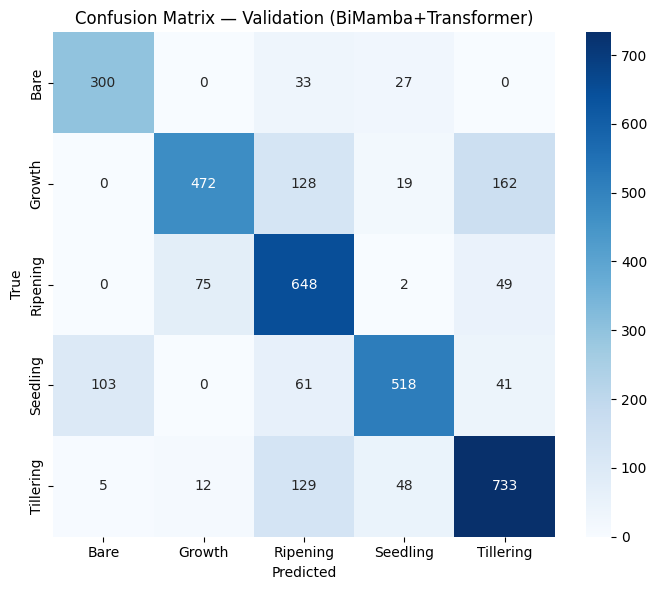


[Test (Unseen Plots)] Loss=0.5926 | Acc=75.01% | Macro-F1=0.7543
  Bare: recall=0.7892
  Growth: recall=0.6539
  Ripening: recall=0.9696
  Seedling: recall=0.7136
  Tillering: recall=0.7511
              precision    recall  f1-score   support

        Bare       0.91      0.79      0.85       332
      Growth       0.91      0.65      0.76       786
    Ripening       0.41      0.97      0.57       427
    Seedling       0.84      0.71      0.77       887
   Tillering       0.90      0.75      0.82      1133

    accuracy                           0.75      3565
   macro avg       0.79      0.78      0.75      3565
weighted avg       0.83      0.75      0.77      3565



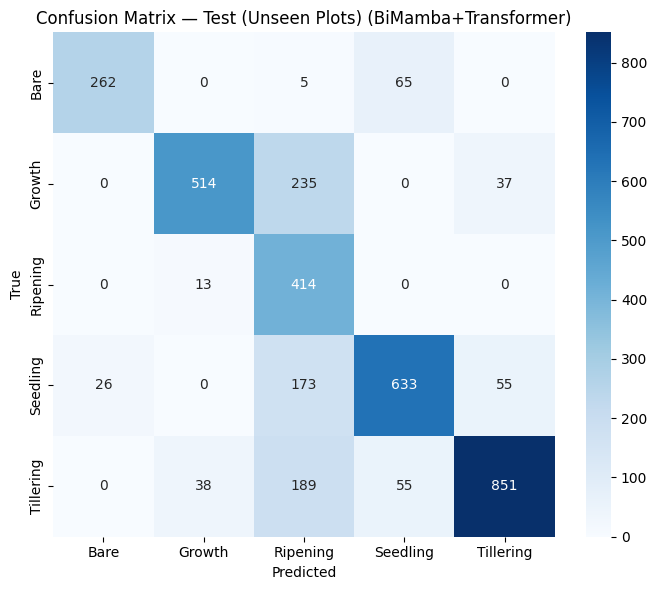


  model_2_v2   BiGRU+Transformer           Test F1: 0.6929
  model_3      PhenoCrop-Presto             Test F1: 0.7600
  model_4 v1   Perceiver+Mamba              Test F1: 0.6200
  model_4 v2   Mamba+Transformer            Test F1: 0.7300
  model_4 v3   BiMamba+Transformer ──►      Test F1: 0.7543


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def evaluate(model, loader, split, device, num_classes, idx_to_stage):
    criterion = FocalLoss(gamma=0)   # plain CE for reporting
    loss, acc, f1, y_true, y_pred = run_epoch(model, loader, criterion, None, device)
    labels = list(range(num_classes))
    names  = [idx_to_stage[i] for i in labels]

    print(f"\n[{split}] Loss={loss:.4f} | Acc={acc*100:.2f}% | Macro-F1={f1:.4f}")
    recalls = recall_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    for i, n, r in zip(labels, names, recalls):
        print(f"  {n}: recall={r:.4f}")
    print(classification_report(y_true, y_pred, labels=labels, target_names=names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    _, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(f"Confusion Matrix — {split} (BiMamba+Transformer)")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return loss, acc, f1


val_loss,  val_acc,  val_f1  = evaluate(trained_model, val_loader,  "Validation",         device, num_classes, idx_to_stage)
test_loss, test_acc, test_f1 = evaluate(trained_model, test_loader, "Test (Unseen Plots)", device, num_classes, idx_to_stage)

print("\n" + "="*62)
print(f"  model_2_v2   BiGRU+Transformer           Test F1: 0.6929")
print(f"  model_3      PhenoCrop-Presto             Test F1: 0.7600")
print(f"  model_4 v1   Perceiver+Mamba              Test F1: 0.6200")
print(f"  model_4 v2   Mamba+Transformer            Test F1: 0.7300")
print(f"  model_4 v3   BiMamba+Transformer ──►      Test F1: {test_f1:.4f}")
print("="*62)

## Cell 11 — Save

In [ ]:
save_path = OUTPUT_DIR / "phenocrop_bimamba_transformer.pth"
torch.save({
    "model_state_dict": trained_model.state_dict(),
    "stage_to_idx":     stage_to_idx,
    "idx_to_stage":     idx_to_stage,
    "num_classes":      num_classes,
    "val_macro_f1":     val_f1,
    "test_macro_f1":    test_f1,
    "hparams": {"d_model":128, "mamba_depth":2, "tf_depth":4, "n_heads":8, "d_state":16},
}, save_path)
print(f"Saved: {save_path}")

trained_model.eval()
rows = []
with torch.no_grad():
    for batch in test_loader:
        logits = trained_model(
            batch["s1"].to(device), batch["s2"].to(device),
            batch["days"].to(device),
            batch["s1_mask"].to(device), batch["s2_mask"].to(device),
        )
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        truths = batch["label"].numpy()
        for i in range(len(preds)):
            row = {"true": idx_to_stage[truths[i]], "pred": idx_to_stage[preds[i]]}
            for c, n in idx_to_stage.items():
                row[f"prob_{n}"] = float(probs[i, c])
            rows.append(row)

pd.DataFrame(rows).to_csv(OUTPUT_DIR / "pred_bimamba_transformer.csv", index=False)
print("Predictions saved.")

Saved: models/phenocrop_bimamba_transformer.pth
Predictions saved.


---
## What's the ceiling and what still limits it?

**Realistic ceiling for this task:** ~0.80–0.83 macro-F1

- Hard ceiling from data noise: cloud contamination in S2 + label uncertainty ≈ 0.83–0.85 theoretical max
- Generalization gap (unseen plots): architecture can't close this; only more diverse training data can

**If still below 0.78 after v3, try (in order of expected impact):**

| Lever | Change | Expected gain |
|---|---|---|
| Scale up | `d_model=192`, `tf_depth=6` | +0.01–0.02 |
| More Mamba | `mamba_depth=3` | +0.005–0.01 |
| Lower focal gamma | Try `gamma=1.0` | ±0.01 |
| Larger window | `MAX_T=48`, `LOOKBACK=150` | +0.005 |
| Ensemble v3+model_3 | Average logits | +0.02–0.03 |

**Easiest +0.02–0.03 boost: ensemble model_3 + model_4v3**
```python
# Average the softmax outputs from both models
probs = 0.5 * softmax(model3_logits) + 0.5 * softmax(model4_logits)
pred  = probs.argmax(dim=1)
```